In [1]:
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from skimage.io import imread
from tqdm.notebook import tqdm

In [2]:
PATH = '../input/alaska2-image-steganalysis'
SRNet = '../input/alaska2-srnet-baseline-inference'
sub = pd.read_csv(os.path.join(SRNet, 'submission.csv'))

FileNotFoundError: [Errno 2] No such file or directory: '../input/alaska2-srnet-baseline-inference/submission.csv'

In [3]:
class JPEGImageCompressionRateDeterminer:
    def __call__(self, image_path):
        image = imread(image_path)
        w, h, c = image.shape
        
        # theoretical image size
        n_bits = w*h*3
        
        # real image file size in bytes
        image_size = os.stat(image_path).st_size
        return (n_bits - image_size) / n_bits 

In [4]:
compression_rate_determiner = JPEGImageCompressionRateDeterminer()

compressions = {}

dir_path = os.path.join(PATH, 'Test')
for impath in tqdm(sub.Id.values):
    c = compression_rate_determiner(os.path.join(dir_path, impath))
    compressions[impath] = c
    if c > 0.95:
        sub.loc[sub.Id == impath, 'Label'] = 1.

NameError: name 'sub' is not defined

/tmp/ipykernel_11/928363453.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(list(compressions.values()));
/usr/local/lib/python3.11/dist-packages/seaborn/distributions.py:2479: RuntimeWarning: Mean of empty slice.
  line, = ax.plot(a.mean(), 0)
/usr/local/lib/python3.11/dist-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/usr/local/lib/python3.11/dist-packages/numpy/lib/histograms.py:885: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


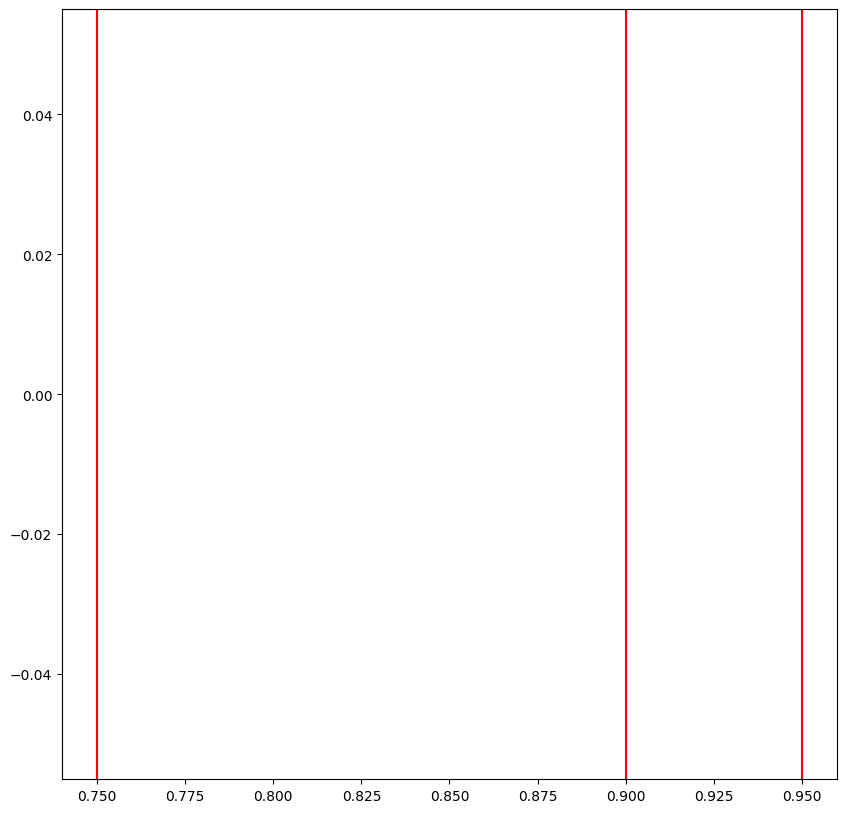

In [5]:
plt.figure(figsize=(10,10))

plt.axvline(0.75, color='red')
plt.axvline(0.90, color='red')
plt.axvline(0.95, color='red')
sns.distplot(list(compressions.values()));

In [6]:
plt.figure(figsize=(10,10))

sns.distplot(sub.Label);

NameError: name 'sub' is not defined

<Figure size 1000x1000 with 0 Axes>

In [7]:
sub.to_csv('submission.csv', index=None)

NameError: name 'sub' is not defined

In [8]:
sub.head()

NameError: name 'sub' is not defined